In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

print(df.shape)

(392693, 16)


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Weekday,Quarter,CustomerFrequency,OrderSize
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday,4,297,Small
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,4,297,Small
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday,4,297,Small
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,4,297,Small
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,4,297,Small


In [4]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [5]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2011-12-10 12:50:00


In [6]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x:
        (
            snapshot_date -
            x.max()
        ).days,

    "Invoice": "count",

    "TotalAmount": "sum"

})

In [7]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [8]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,90.523974,2048.692230
std,100.014169,225.506929,8985.229676
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,306.482500
50%,51.000000,41.000000,668.570000
75%,142.000000,98.000000,1660.597500
max,374.000000,7676.000000,280206.020000


In [9]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)

In [10]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(
        kmeans.inertia_
    )

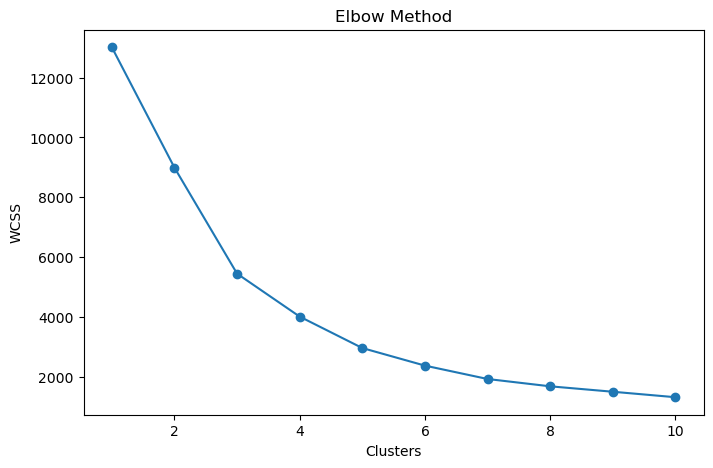

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [12]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = (
    kmeans.fit_predict(
        rfm_scaled
    )
)

In [13]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,1,77183.60,1
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,0
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,1


In [14]:
rfm["Cluster"].value_counts()

Cluster
0    3247
1    1081
2       6
3       4
Name: count, dtype: int64

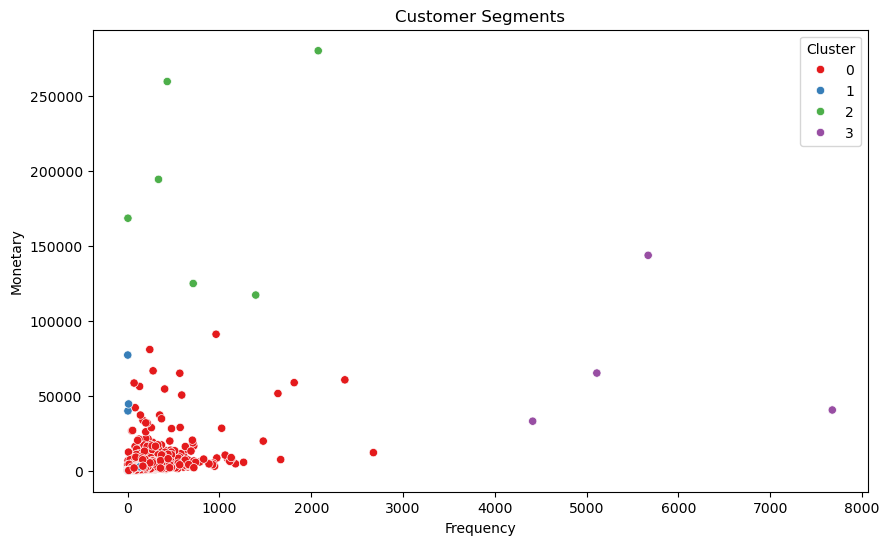

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title(
    "Customer Segments"
)

plt.show()

In [16]:
cluster_summary = rfm.groupby(
    "Cluster"
).mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,41.310440,103.247613,2085.870463
1,247.209991,27.404255,635.620066
2,7.666667,825.833333,190808.536667
3,2.000000,5717.250000,70612.247500


In [17]:
cluster_names = {

    0: "Regular",

    1: "VIP",

    2: "Loyal",

    3: "At Risk"

}

In [18]:
rfm["Segment"] = (
    rfm["Cluster"]
    .map(cluster_names)
)

In [19]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,326,1,77183.60,1,VIP
12347.0,2,182,4310.00,0,Regular
12348.0,75,31,1797.24,0,Regular
12349.0,19,73,1757.55,0,Regular
12350.0,310,17,334.40,1,VIP


In [20]:
rfm.to_csv(
    "../data/rfm_segmented.csv"
)

print(
    "Customer Segmentation Saved"
)

Customer Segmentation Saved
